In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.metrics import (f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, 
                             classification_report, precision_score)


def read_json_result(path):
    with open(path) as f :
        json_str = f.read()
        out =  json.loads(json_str)

    test = pd.read_csv("Test.csv")

    fails = 0
    list_out = []
    Nan_out = 0
    for new in out:
        if new["status"] == "FAIL":
            fails += 1
        else:
            if type(new['result']) == int:
                list_out.append([new["id"], new["result"], test["label"][int(new["id"])]])
            else:
                Nan_out += 1
    df_out = pd.DataFrame(list_out, columns=["id", "predict", "label"])
    return df_out, fails, Nan_out

def get_metrics(df, predict, label):
    le = preprocessing.LabelEncoder()
    enc = preprocessing.OneHotEncoder()
    label = le.fit_transform(df[label]).reshape(-1,1)
    enc.fit(label)
    transformed_label = enc.transform(label).toarray()
    results = []
    pred = le.transform(df[predict]).reshape(-1,1)
    transformed_predict = enc.transform(pred).toarray()
    f1 = f1_score(transformed_label, transformed_predict, average = "micro")
    acc = accuracy_score(transformed_label, transformed_predict)
    prec = precision_score(transformed_label, transformed_predict, average = "micro")
    results.append([predict, f1, acc, prec])
    results = pd.DataFrame(results, columns=["Modelo", "f1_score", "Accuracy", "Precison"])
    return results

def plot_confusion_matrix(df, predict, label):
    le = preprocessing.LabelEncoder()
    enc = preprocessing.OneHotEncoder()
    le.fit([1, 0, -1])
    label = le.transform(df[label]).reshape(-1,1)
    enc.fit(label)
    transformed_label = enc.transform(label).toarray()
    print(predict)
    pred = le.transform(df[predict]).reshape(-1,1)
    transformed_predict = enc.transform(pred).toarray()
    cm = confusion_matrix(transformed_label.argmax(axis=1), transformed_predict.argmax(axis=1))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                    display_labels=["neg", "neu", "pos"])

    disp.plot()
    plt.show()    
    print(classification_report(transformed_label, transformed_predict, 
                                target_names=["neg", "neu", "pos"]))   

# Text analyzer 3.5 Witout Retrival

In [2]:

df_wr, fails_wr, Nan_wr = read_json_result("out_without_retrival.json")
print(get_metrics(df_wr, "predict", "label"))  
plot_confusion_matrix(df_wr, "predict", "label")  

ValueError: Target is multilabel-indicator but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted', 'samples'].

# Text analyzer 3.5 Retrival K = 1

    Modelo  f1_score  Accuracy
0  predict  0.761905  0.761905
predict


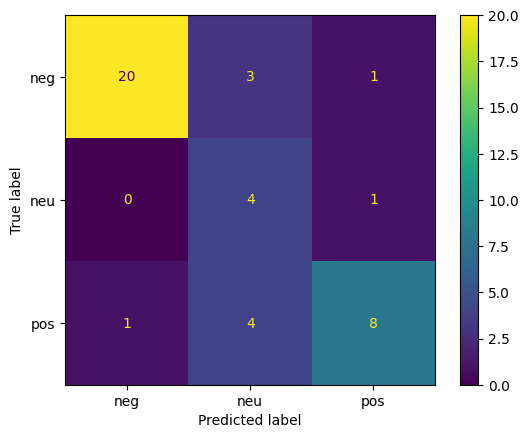

              precision    recall  f1-score   support

         neg       0.95      0.83      0.89        24
         neu       0.36      0.80      0.50         5
         pos       0.80      0.62      0.70        13

   micro avg       0.76      0.76      0.76        42
   macro avg       0.71      0.75      0.69        42
weighted avg       0.84      0.76      0.78        42
 samples avg       0.76      0.76      0.76        42



In [3]:

df_r1, fails_r1, Nan_r1 = read_json_result("out_retrival_1.json")
print(get_metrics(df_r1, "predict", "label"))  
plot_confusion_matrix(df_r1, "predict", "label") 

# Text analyzer 3.5 Retrival K = 2

    Modelo  f1_score  Accuracy
0  predict  0.761905  0.761905
predict


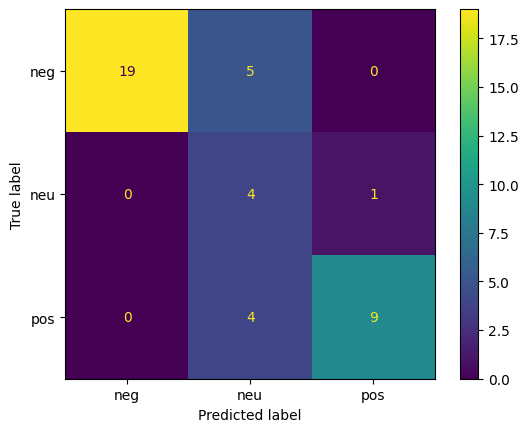

              precision    recall  f1-score   support

         neg       1.00      0.79      0.88        24
         neu       0.31      0.80      0.44         5
         pos       0.90      0.69      0.78        13

   micro avg       0.76      0.76      0.76        42
   macro avg       0.74      0.76      0.70        42
weighted avg       0.89      0.76      0.80        42
 samples avg       0.76      0.76      0.76        42



In [19]:
df_r2, fails_r2, Nan_r2 = read_json_result("out_retrival_2.json")
df_r2.loc[len(df_r2.index)] = [46, 0, 0]
print(get_metrics(df_r2, "predict", "label"))  
plot_confusion_matrix(df_r2, "predict", "label") 

# Text analyzer 4 Whitout Retrival

    Modelo  f1_score  Accuracy
0  predict   0.73913   0.73913
predict


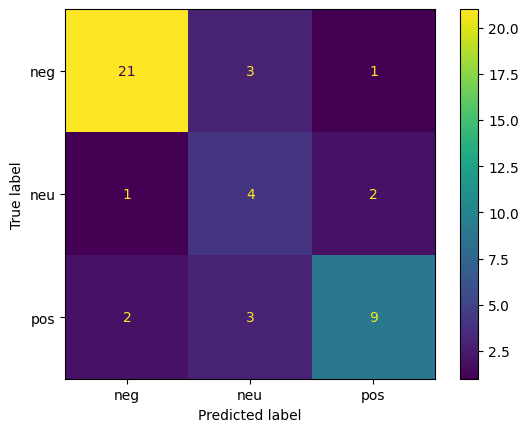

              precision    recall  f1-score   support

         neg       0.88      0.84      0.86        25
         neu       0.40      0.57      0.47         7
         pos       0.75      0.64      0.69        14

   micro avg       0.74      0.74      0.74        46
   macro avg       0.67      0.68      0.67        46
weighted avg       0.76      0.74      0.75        46
 samples avg       0.74      0.74      0.74        46



In [13]:

df_wr, fails_wr, Nan_wr = read_json_result("out_without_retrival_4.json")
print(get_metrics(df_wr, "predict", "label"))  
plot_confusion_matrix(df_wr, "predict", "label")  

# Text analyzer 4 Retrival K = 1

    Modelo  f1_score  Accuracy
0  predict  0.777778  0.777778
predict


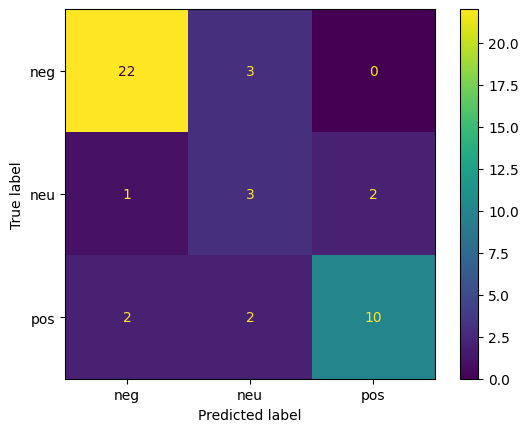

              precision    recall  f1-score   support

         neg       0.88      0.88      0.88        25
         neu       0.38      0.50      0.43         6
         pos       0.83      0.71      0.77        14

   micro avg       0.78      0.78      0.78        45
   macro avg       0.70      0.70      0.69        45
weighted avg       0.80      0.78      0.79        45
 samples avg       0.78      0.78      0.78        45



In [7]:
df_r1, fails_r1, Nan_r1 = read_json_result("out_retrival_1_4.json")
print(get_metrics(df_r1, "predict", "label"))  
plot_confusion_matrix(df_r1, "predict", "label") 

# Text analyzer 4 Retrival K = 2

    Modelo  f1_score  Accuracy
0  predict  0.852941  0.852941
predict


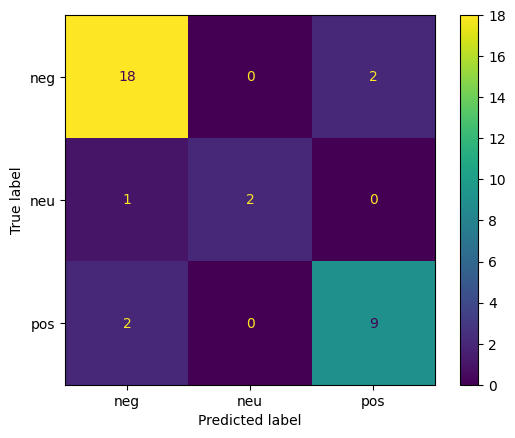

              precision    recall  f1-score   support

         neg       0.86      0.90      0.88        20
         neu       1.00      0.67      0.80         3
         pos       0.82      0.82      0.82        11

   micro avg       0.85      0.85      0.85        34
   macro avg       0.89      0.79      0.83        34
weighted avg       0.86      0.85      0.85        34
 samples avg       0.85      0.85      0.85        34



In [16]:
df_r2, fails_r2, Nan_r2 = read_json_result("out_retrival_2_4.json")
df_r2.loc[len(df_r2.index)] = [46, 0, 0]
print(get_metrics(df_r2, "predict", "label"))  
plot_confusion_matrix(df_r2, "predict", "label") 

# Text analyzer 4 Retrival K = 3

In [ ]:
df_r3, fails_r3, Nan_r3 = read_json_result("out_retrival_3_4.json")
df_r3.loc[len(df_r3.index)] = [46, 0, 0]
print(get_metrics(df_r3, "predict", "label"))  
plot_confusion_matrix(df_r3, "predict", "label") 

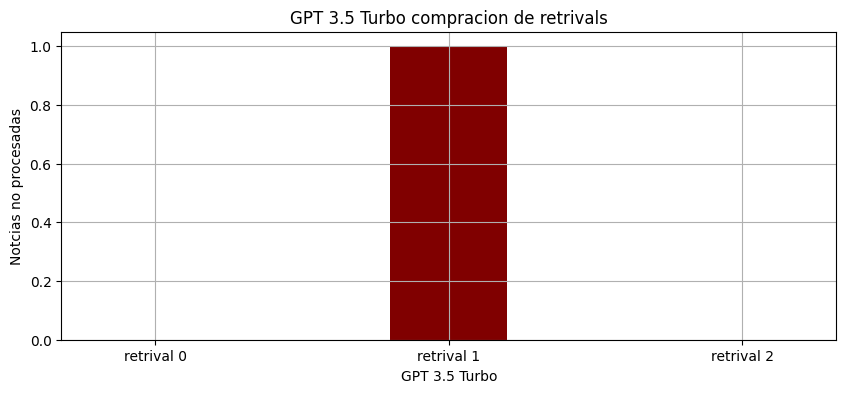

In [14]:
# creating the dataset
data = {'retrival 0':fails_wr, 'retrival 1':fails_r1, 'retrival 2':fails_r2}
courses = list(data.keys())
values = list(data.values())
  
fig = plt.figure(figsize = (10, 4))
 
# creating the bar plot
plt.bar(courses, values, color ='maroon', 
        width = 0.4)
 
plt.xlabel("GPT 3.5 Turbo")
plt.ylabel("Notcias no procesadas")
plt.title("GPT 3.5 Turbo compracion de retrivals")
plt.grid(zorder=0)
plt.show()

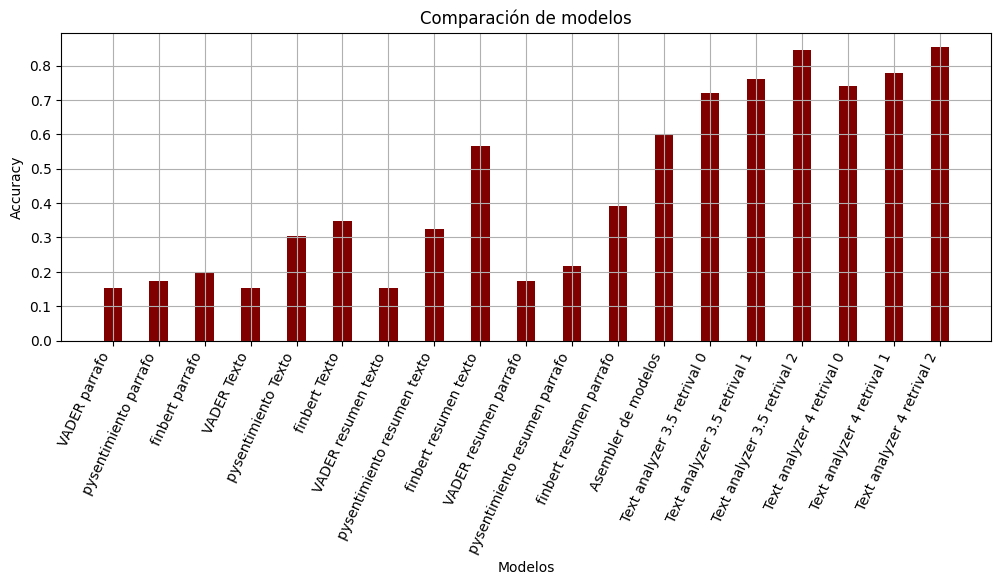

In [2]:
# creating the dataset
data = {"VADER parrafo": 0.152174, "pysentimiento parrafo": 0.173913, "finbert parrafo": 0.195652, "VADER Texto": 0.152174, 
        "pysentimiento Texto": 0.304348, "finbert Texto": 0.347826, "VADER resumen texto": 0.152174, 
        "pysentimiento resumen texto": 0.326087, "finbert resumen texto": 0.565217, "VADER resumen parrafo": 0.173913, 
        "pysentimiento resumen parrafo": 0.217391, "finbert resumen parrafo": 0.391304, 'Asembler de modelos': 0.597826, 
        'Text analyzer 3.5 retrival 0':0.72093, 
        'Text analyzer 3.5 retrival 1': 0.761905, 'Text analyzer 3.5 retrival 2': 0.846154, 'Text analyzer 4 retrival 0': 0.73913,
        'Text analyzer 4 retrival 1': 0.777778, 'Text analyzer 4 retrival 2': 0.852941}
courses = list(data.keys())
values = list(data.values())
  
fig = plt.figure(figsize = (12, 4))
 
# creating the bar plot
plt.bar(courses, values, color ='maroon', 
        width = 0.4)
 
plt.xlabel("Modelos")
plt.ylabel("Accuracy")
plt.title("Comparación de modelos")
plt.grid(zorder=0)
plt.xticks(rotation=65, ha='right')
plt.show()

In [3]:
import plotly.express as px
import pandas as pd
data = {"VADER parrafo": 0.152174, "pysentimiento parrafo": 0.173913, "finbert parrafo": 0.195652, "VADER Texto": 0.152174, 
        "pysentimiento Texto": 0.304348, "finbert Texto": 0.347826, "VADER resumen texto": 0.152174, 
        "pysentimiento resumen texto": 0.326087, "finbert resumen texto": 0.565217, "VADER resumen parrafo": 0.173913, 
        "pysentimiento resumen parrafo": 0.217391, "finbert resumen parrafo": 0.391304, 'Asembler de modelos': 0.597826, 
        'Text analyzer 3.5 retrival 0':0.72093, 
        'Text analyzer 3.5 retrival 1': 0.761905, 'Text analyzer 3.5 retrival 2': 0.846154, 'Text analyzer 4 retrival 0': 0.73913,
        'Text analyzer 4 retrival 1': 0.777778, 'Text analyzer 4 retrival 2': 0.852941}

data = pd.DataFrame(data.items(), columns=["Modelo", "Accuracy"])
fig = px.bar(data, x='Modelo', y='Accuracy', title="Comparación de modelos", labels={'Modelo':'Modelo', 'Accuracy':'Accuracy'}, text_auto=True)
fig.update_traces(textfont_size=12, textangle=0, textposition="outside", cliponaxis=False)
fig.show()